# Cost Taxonomy and Fee Schedules

**Docker image**: `ml4t`

This notebook builds a unit-aware transaction-cost taxonomy across six
liquid-market groups. It separates observed activity, sourced fee schedules,
and illustrative cost scenarios so that unlike quantities are not ranked as
if they were directly comparable.

**Learning Objectives:**
- Preserve each market's native volume and fee units
- Compute daily dollar turnover only where a defensible conversion exists
- Compare commission, spread, and impact in explicit scenarios
- Validate the cost schemas in all nine case-study setup files
- Map breakeven alpha over transparent turnover and cost assumptions

**Book Reference:** Chapter 18, Sections 18.1 (Why Costs Matter) and
18.2 (Cost Components)

**Prerequisites:** Access to all six OHLCV datasets covered here and
case study `config/setup.yaml` files.

In [1]:
"""Cost taxonomy and fee schedules for unit-aware scenario analysis."""

import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import yaml
from _cost_analysis import breakeven_alpha
from IPython.display import Markdown, display
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

from data import (
    load_cme_futures,
    load_crypto_perps,
    load_etfs,
    load_fx_pairs,
    load_sp500_daily_bars,
    load_us_equities,
)
from utils.paths import REPO_ROOT, get_case_study_source_dir
from utils.style import COLORS, add_message_title, ml4t_palette

In [2]:
MAX_SYMBOLS = 0  # 0 = all symbols
SOURCE_CHECK_DATE = "2026-07-21"

## 1. Liquidity Has Units

Average daily volume (ADV) can mean shares, contracts, base-asset units, or
quote updates. A dollar conversion is valid only when price and volume form a
traded notional. We therefore compare dollar turnover where that conversion
is defined and report ETF share activity and FX tick activity separately.
`MAX_SYMBOLS` selects an alphabetical prefix only to bound test runs; it is
not a liquidity screen.

In [3]:
def limit_symbols(df: pl.DataFrame, symbol_col: str) -> pl.DataFrame:
    """Apply a deterministic test-only symbol limit without ranking on future data."""
    if MAX_SYMBOLS <= 0:
        return df
    symbols = df.select(symbol_col).unique().sort(symbol_col).head(MAX_SYMBOLS)
    return df.join(symbols, on=symbol_col, how="semi")

### Daily Dollar-Turnover Summary

Each input to this helper is already daily and carries a defensible dollar
turnover column. The output retains the observation window so that a reader
can see when markets are not contemporaneous.

In [4]:
def summarize_dollar_turnover(
    df: pl.DataFrame,
    symbol_col: str,
    date_col: str,
    asset_class: str,
) -> pl.DataFrame:
    """Summarize a precomputed daily dollar-turnover column by instrument."""
    return (
        df.group_by(symbol_col)
        .agg(
            adv_usd=pl.col("daily_turnover_usd").mean(),
            coverage_start=pl.col(date_col).min().cast(pl.Date),
            coverage_end=pl.col(date_col).max().cast(pl.Date),
        )
        .rename({symbol_col: "symbol"})
        .with_columns(asset_class=pl.lit(asset_class))
        .select("symbol", "asset_class", "adv_usd", "coverage_start", "coverage_end")
    )

### Equity Dollar Turnover

Daily share volume multiplied by the traded close gives approximate daily
dollar turnover. These two panels retain their own source windows.

In [5]:
adv_records = []
for asset_class, frame in {
    "US Equities": limit_symbols(load_us_equities(), "symbol"),
    "S&P 500 Equities": limit_symbols(load_sp500_daily_bars(), "symbol"),
}.items():
    daily = frame.with_columns(daily_turnover_usd=pl.col("close") * pl.col("volume"))
    adv_records.append(summarize_dollar_turnover(daily, "symbol", "timestamp", asset_class))

### Crypto Daily Quote Turnover

Binance volume is base-asset quantity. The loader returns three funding-aligned
bars per day, so we sum quote turnover by UTC date before computing ADV.

In [6]:
crypto = limit_symbols(load_crypto_perps(frequency="8h"), "symbol")
crypto_daily = (
    crypto.with_columns(
        activity_date=pl.col("timestamp").dt.date(),
        bar_turnover_usd=pl.col("close") * pl.col("volume"),
    )
    .group_by("symbol", "activity_date")
    .agg(daily_turnover_usd=pl.col("bar_turnover_usd").sum())
)
adv_records.append(
    summarize_dollar_turnover(
        crypto_daily,
        "symbol",
        "activity_date",
        "Crypto Perpetuals",
    )
)

### CME Contract-Notional Turnover

Futures volume counts contracts. The price multiplier is derived from tick
value divided by tick size, matching the backtest contract specification.

In [7]:
spec_path = REPO_ROOT / "data" / "futures" / "market" / "futures_specs.yaml"
product_specs = yaml.safe_load(spec_path.read_text())["products"]
multiplier_df = pl.DataFrame(
    [
        {
            "product": product,
            "price_multiplier": float(spec["tick_value"]) / float(spec["tick_size"]),
        }
        for product, spec in product_specs.items()
    ]
)

cme = limit_symbols(load_cme_futures(tenors=[0]), "product").join(
    multiplier_df,
    on="product",
    how="left",
)
missing_multipliers = cme.filter(pl.col("price_multiplier").is_null())["product"].unique().to_list()
if missing_multipliers:
    raise ValueError(f"Missing CME multipliers for: {sorted(missing_multipliers)}")

cme = cme.with_columns(
    daily_turnover_usd=pl.col("volume") * pl.col("raw_close") * pl.col("price_multiplier")
)
adv_records.append(summarize_dollar_turnover(cme, "product", "session_date", "CME Futures"))

all_adv = pl.concat(adv_records)

### ETF Share Activity

Yahoo supplies adjusted OHLC together with observed share volume. Without raw
historical closes or adjustment factors, multiplying these fields would not
recover contemporaneous traded notional. ETF activity therefore remains in
its native shares-per-day unit.

In [8]:
etfs = limit_symbols(load_etfs(), "symbol")
etf_activity = (
    etfs.group_by("symbol")
    .agg(
        mean_daily_shares=pl.col("volume").mean(),
        coverage_start=pl.col("timestamp").min().cast(pl.Date),
        coverage_end=pl.col("timestamp").max().cast(pl.Date),
    )
    .sort("mean_daily_shares", descending=True)
)
etf_activity

symbol,mean_daily_shares,coverage_start,coverage_end
str,f64,date,date
"""SPY""",1.2621e8,2006-01-03,2025-12-31
"""XLF""",7.3482e7,2006-01-03,2025-12-31
"""QQQ""",6.3756e7,2006-01-03,2025-12-31
"""EEM""",5.3074e7,2006-01-03,2025-12-31
"""IWM""",4.3071e7,2006-01-03,2025-12-31
…,…,…,…
"""FXY""",201230.597643,2007-02-13,2025-12-31
"""THD""",172415.980304,2008-04-01,2025-12-31
"""EWN""",167001.669648,2006-01-03,2025-12-31


### FX Tick Activity

OANDA daily volume counts price updates rather than traded currency. It can
describe activity within this dataset, but it cannot share a USD ADV axis.

In [9]:
fx = limit_symbols(load_fx_pairs(frequency="daily"), "symbol")
fx_activity = (
    fx.group_by("symbol")
    .agg(
        mean_daily_ticks=pl.col("volume").mean(),
        coverage_start=pl.col("timestamp").min().cast(pl.Date),
        coverage_end=pl.col("timestamp").max().cast(pl.Date),
    )
    .sort("mean_daily_ticks", descending=True)
)
fx_activity

symbol,mean_daily_ticks,coverage_start,coverage_end
str,f64,date,date
"""GBP_AUD""",171330.345896,2011-01-03,2025-12-31
"""GBP_JPY""",141758.146102,2011-01-03,2025-12-31
"""EUR_CAD""",130539.626742,2011-01-03,2025-12-31
"""GBP_CHF""",114460.341766,2011-01-03,2025-12-31
"""CHF_JPY""",112966.570212,2011-01-03,2025-12-31
…,…,…,…
"""NZD_USD""",45192.862416,2011-01-03,2025-12-31
"""EUR_CHF""",37736.820857,2011-01-03,2025-12-31
"""EUR_GBP""",36985.227155,2011-01-03,2025-12-31


### Comparable Dollar-Turnover Summary

In [10]:
adv_summary = (
    all_adv.group_by("asset_class")
    .agg(
        n_symbols=pl.col("symbol").n_unique(),
        median_adv_usd=pl.col("adv_usd").median(),
        p25_adv_usd=pl.col("adv_usd").quantile(0.25),
        p75_adv_usd=pl.col("adv_usd").quantile(0.75),
        coverage_start=pl.col("coverage_start").min(),
        coverage_end=pl.col("coverage_end").max(),
    )
    .sort("median_adv_usd", descending=True)
)
adv_summary

asset_class,n_symbols,median_adv_usd,p25_adv_usd,p75_adv_usd,coverage_start,coverage_end
str,u32,f64,f64,f64,date,date
"""CME Futures""",30,5.9578e9,2.8185e9,2.9539e10,2011-01-03,2025-12-31
"""Crypto Perpetuals""",19,3.5510e8,1.5786e8,1.0323e9,2020-01-01,2025-12-31
"""S&P 500 Equities""",638,1.5994e8,1.0420e8,2.8571e8,2017-01-03,2021-12-31
"""US Equities""",3199,8.1978e6,2.4623e6,2.7960e7,1962-01-02,2018-03-27


### Dollar-Turnover Distribution

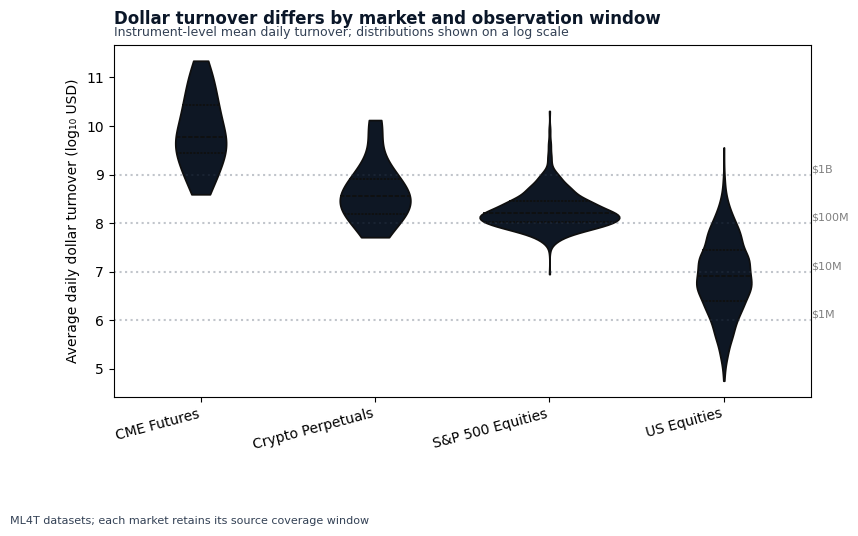

In [11]:
adv_pd = all_adv.filter(pl.col("adv_usd") > 0).to_pandas()
adv_pd["log_adv_usd"] = np.log10(adv_pd["adv_usd"])

order = (
    all_adv.group_by("asset_class")
    .agg(pl.col("adv_usd").median())
    .sort("adv_usd", descending=True)["asset_class"]
    .to_list()
)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.violinplot(
    data=adv_pd,
    x="asset_class",
    y="log_adv_usd",
    order=order,
    ax=ax,
    inner="quartile",
    cut=0,
    color=COLORS["blue"],
)
ax.set_ylabel("Average daily dollar turnover (log₁₀ USD)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=15)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

for val, label in [(6, "$1M"), (7, "$10M"), (8, "$100M"), (9, "$1B")]:
    ax.axhline(val, color=COLORS["neutral"], linestyle=":", alpha=0.3)
    ax.text(len(order) - 0.5, val + 0.05, label, fontsize=8, alpha=0.5)

add_message_title(
    ax,
    "Dollar turnover differs by market and observation window",
    subtitle="Instrument-level mean daily turnover; distributions shown on a log scale",
    source="ML4T datasets; each market retains its source coverage window",
)
fig.subplots_adjust(bottom=0.24)
fig.show()

In [12]:
highest_turnover_market = adv_summary.row(0, named=True)
display(
    Markdown(
        f"**Reading the chart:** {highest_turnover_market['asset_class']} has the highest "
        f"median daily dollar turnover in this sample. The comparison is descriptive, not a "
        f"capacity estimate, because coverage ranges from "
        f"{adv_summary['coverage_start'].min()} to {adv_summary['coverage_end'].max()}. "
        "ETFs remain separate because adjusted prices cannot be paired with observed share "
        "volume for historical notional; FX remains separate because tick volume has no "
        "dollar-notional conversion."
    )
)

**Reading the chart:** CME Futures has the highest median daily dollar turnover in this sample. The comparison is descriptive, not a capacity estimate, because coverage ranges from 1962-01-02 to 2025-12-31. ETFs remain separate because adjusted prices cannot be paired with observed share volume for historical notional; FX remains separate because tick volume has no dollar-notional conversion.

## 2. Exchange Fee Schedules

Fees use different denominators. Stocks charge per share, futures and options
per contract, FX through a variable spread, and crypto per unit of notional.
The table preserves those charging units and separates sourced rates from
case-study assumptions.

### Fee Evidence Row

Each row carries its source and evidence status. A text rate is deliberate:
it prevents accidental arithmetic across incompatible charging units.

In [13]:
def fee_evidence_row(
    venue: str,
    instrument: str,
    rate: str,
    status: str,
    source: str,
) -> dict:
    """Create one source-dated fee row without coercing its charging unit."""
    return {
        "venue": venue,
        "instrument": instrument,
        "rate": rate,
        "status": status,
        "source": source,
    }

In [14]:
fee_source_urls = {
    "IBKR stocks": "https://www.interactivebrokers.com/en/pricing/commissions-stocks.php",
    "IBKR commissions": "https://www.interactivebrokers.com/en/pricing/commissions-home.php?menu=A",
    "NFA assessment FAQ": "https://www.nfa.futures.org/faqs/members/nfa-assessment-fees.html",
    "CME fee finder": "https://www.cmegroup.com/company/clearing-fees/fee-finder.html",
    "OANDA pricing": "https://www.oanda.com/us-en/trading/our-pricing/",
    "crypto setup.yaml": "case_studies/crypto_perps_funding/config/setup.yaml",
}

The first rows have explicit, dated values in official schedules.

In [15]:
fee_rows = [
    fee_evidence_row(
        "IBKR", "US stocks, Pro Tiered first tier", "USD 0.0035/share", "official", "IBKR stocks"
    ),
    fee_evidence_row("IBKR", "US stocks, Pro Fixed", "USD 0.005/share", "official", "IBKR stocks"),
    fee_evidence_row(
        "IBKR", "US options, Pro Fixed", "USD 0.65/contract", "official", "IBKR commissions"
    ),
    fee_evidence_row(
        "NFA",
        "Futures assessment",
        "USD 0.01/contract/side",
        "effective 2026-07-01",
        "NFA assessment FAQ",
    ),
]

Variable schedules retain their native qualification. Binance remains a
case-study assumption because the public fee page is account-dependent.

In [16]:
fee_rows.extend(
    [
        fee_evidence_row(
            "CME",
            "Futures exchange fee",
            "Product and account specific",
            "official fee finder",
            "CME fee finder",
        ),
        fee_evidence_row(
            "OANDA",
            "Spot FX spread-only plan",
            "Pair- and market-dependent",
            "official description",
            "OANDA pricing",
        ),
        fee_evidence_row(
            "Binance USDT-M",
            "Perpetual taker example",
            "Account-tier dependent; see case-study configuration",
            "case-study assumption",
            "crypto setup.yaml",
        ),
    ]
)
fee_schedule_df = pl.DataFrame(fee_rows).with_columns(
    source_url=pl.col("source").replace_strict(fee_source_urls),
    source_checked=pl.lit(SOURCE_CHECK_DATE),
)
fee_schedule_df

venue,instrument,rate,status,source,source_url,source_checked
str,str,str,str,str,str,str
"""IBKR""","""US stocks, Pro Tiered first ti…","""USD 0.0035/share""","""official""","""IBKR stocks""","""https://www.interactivebrokers…","""2026-07-21"""
"""IBKR""","""US stocks, Pro Fixed""","""USD 0.005/share""","""official""","""IBKR stocks""","""https://www.interactivebrokers…","""2026-07-21"""
"""IBKR""","""US options, Pro Fixed""","""USD 0.65/contract""","""official""","""IBKR commissions""","""https://www.interactivebrokers…","""2026-07-21"""
"""NFA""","""Futures assessment""","""USD 0.01/contract/side""","""effective 2026-07-01""","""NFA assessment FAQ""","""https://www.nfa.futures.org/fa…","""2026-07-21"""
"""CME""","""Futures exchange fee""","""Product and account specific""","""official fee finder""","""CME fee finder""","""https://www.cmegroup.com/compa…","""2026-07-21"""
"""OANDA""","""Spot FX spread-only plan""","""Pair- and market-dependent""","""official description""","""OANDA pricing""","""https://www.oanda.com/us-en/tr…","""2026-07-21"""
"""Binance USDT-M""","""Perpetual taker example""","""Account-tier dependent; see ca…","""case-study assumption""","""crypto setup.yaml""","""case_studies/crypto_perps_fund…","""2026-07-21"""


**Interpretation:** A notional order size alone cannot normalize this table.
Per-share scenarios also need the share price. Contract scenarios need a
premium or futures price and multiplier. FX needs the realized spread, while
crypto rates can vary by account tier. The next section therefore uses named,
transparent scenarios rather than presenting a venue ranking.

## 3. Cost Component Dominance

The following parameters are illustrative, not calibrated estimates. Holding
them visible lets us ask a conditional question: under each scenario, which
component is largest at a given trade size?

In [17]:
cost_params = {
    "ETFs": {
        "commission_bps": 1.0,
        "spread_bps": 3.0,
        "impact_eta": 0.05,
        "sigma": 0.015,
        "adv_usd": 5e8,
    },
    "Crypto Perps": {
        "commission_bps": 4.0,
        "spread_bps": 2.0,
        "impact_eta": 0.03,
        "sigma": 0.04,
        "adv_usd": 1e9,
    },
    "CME Futures": {
        "commission_bps": 1.5,
        "spread_bps": 1.5,
        "impact_eta": 0.04,
        "sigma": 0.01,
        "adv_usd": 2e9,
    },
    "FX Pairs": {
        "commission_bps": 0.0,
        "spread_bps": 2.0,
        "impact_eta": 0.02,
        "sigma": 0.005,
        "adv_usd": 5e9,
    },
}

The equity scenarios extend the same illustrative parameter grid.

In [18]:
cost_params |= {
    "S&P 500": {
        "commission_bps": 1.0,
        "spread_bps": 2.0,
        "impact_eta": 0.05,
        "sigma": 0.015,
        "adv_usd": 1e8,
    },
    "US Equities": {
        "commission_bps": 1.0,
        "spread_bps": 8.0,
        "impact_eta": 0.10,
        "sigma": 0.025,
        "adv_usd": 5e6,
    },
}

scenario_df = pl.DataFrame(
    [{"asset_class": asset, **params} for asset, params in cost_params.items()]
).sort("asset_class")
scenario_df

asset_class,commission_bps,spread_bps,impact_eta,sigma,adv_usd
str,f64,f64,f64,f64,f64
"""CME Futures""",1.5,1.5,0.04,0.01,2.0000e9
"""Crypto Perps""",4.0,2.0,0.03,0.04,1.0000e9
"""ETFs""",1.0,3.0,0.05,0.015,5e8
"""FX Pairs""",0.0,2.0,0.02,0.005,5.0000e9
"""S&P 500""",1.0,2.0,0.05,0.015,1e8
"""US Equities""",1.0,8.0,0.1,0.025,5e6


### Component Calculator

In [19]:
def cost_components(size: float, params: dict) -> dict:
    """Compute commission, spread, and square-root impact in basis points."""
    participation = size / params["adv_usd"]
    impact = params["impact_eta"] * params["sigma"] * np.sqrt(participation) * 10_000
    return {
        "Commission": params["commission_bps"],
        "Spread": params["spread_bps"],
        "Impact": impact,
    }

In [20]:
def dominant_component_label(costs: dict[str, float]) -> str:
    """Name the largest component or all components tied for largest."""
    largest = max(costs.values())
    leaders = [name for name, value in costs.items() if np.isclose(value, largest)]
    return " + ".join(leaders)

### Map the Dominant Cost Component by Trade Size

In [21]:
dominance_rows = []
size_labels = ["$10K", "$100K", "$1M", "$10M", "$100M"]
size_values = [1e4, 1e5, 1e6, 1e7, 1e8]

for asset, params in cost_params.items():
    for size, label in zip(size_values, size_labels, strict=False):
        costs = cost_components(size, params)
        dominant = dominant_component_label(costs)
        total = sum(costs.values())

        dominance_rows.append(
            {
                "asset_class": asset,
                "trade_size": label,
                "trade_size_usd": size,
                "dominant": dominant,
                "total_bps": total,
                "commission_frac": costs["Commission"] / total if total > 0 else 0,
                "spread_frac": costs["Spread"] / total if total > 0 else 0,
                "impact_frac": costs["Impact"] / total if total > 0 else 0,
            }
        )

dominance = pl.DataFrame(dominance_rows)

### Dominance Map and Crossover Sizes

Cell color identifies the largest component or an exact tie. The annotation
reports total one-way cost for context. This design keeps dominance distinct
from magnitude.

In [22]:
component_codes = {"Commission": 0, "Spread": 1, "Impact": 2, "Commission + Spread": 3}
dominance = dominance.with_columns(
    component_code=pl.col("dominant").replace_strict(component_codes, return_dtype=pl.Int8)
)
dom_pivot = dominance.pivot(on="trade_size", index="asset_class", values="component_code")
col_order = ["asset_class"] + size_labels
dom_pivot = dom_pivot.select([c for c in col_order if c in dom_pivot.columns])

data = dom_pivot.drop("asset_class").to_numpy()
asset_names = dom_pivot["asset_class"].to_list()
total_lookup = {
    (row["asset_class"], row["trade_size"]): row["total_bps"]
    for row in dominance.iter_rows(named=True)
}

The chart uses the shared ML4T palette for the three components and a tie class.

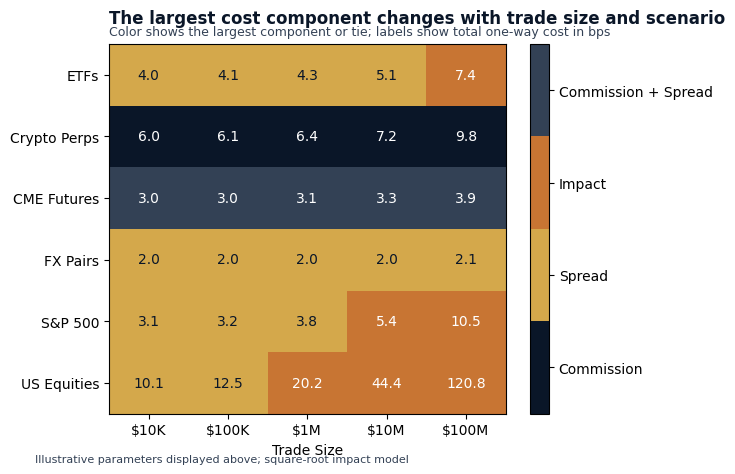

In [23]:
fig, ax = plt.subplots()
dominance_cmap = ListedColormap(
    [COLORS["blue"], COLORS["amber"], COLORS["copper"], COLORS["neutral"]]
)
im = ax.imshow(data, cmap=dominance_cmap, aspect="auto", vmin=-0.5, vmax=3.5)
ax.set_xticks(range(len(size_labels)))
ax.set_xticklabels(size_labels)
ax.set_yticks(range(len(asset_names)))
ax.set_yticklabels(asset_names)
ax.set_xlabel("Trade Size")

for i in range(len(asset_names)):
    for j in range(len(size_labels)):
        total_bps = total_lookup[(asset_names[i], size_labels[j])]
        text_color = "white" if data[i, j] in (0, 2, 3) else COLORS["blue"]
        ax.text(j, i, f"{total_bps:.1f}", ha="center", va="center", color=text_color)

colorbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2, 3])
colorbar.ax.set_yticklabels(["Commission", "Spread", "Impact", "Commission + Spread"])
add_message_title(
    ax,
    "The largest cost component changes with trade size and scenario",
    subtitle="Color shows the largest component or tie; labels show total one-way cost in bps",
    source="Illustrative parameters displayed above; square-root impact model",
)
fig.show()

The impact crossover solves for the order size at which modeled impact equals
the larger fixed component. A crossover outside the displayed range explains
why some rows retain the same color throughout the chart.

In [24]:
crossover_rows = []
for asset, params in cost_params.items():
    fixed_component = max(params["commission_bps"], params["spread_bps"])
    impact_scale = params["impact_eta"] * params["sigma"] * 10_000
    crossover_usd = params["adv_usd"] * (fixed_component / impact_scale) ** 2
    crossover_rows.append(
        {
            "asset_class": asset,
            "largest_fixed_component_bps": fixed_component,
            "impact_crossover_usd": crossover_usd,
        }
    )

crossover_df = pl.DataFrame(crossover_rows).sort("impact_crossover_usd")
crossover_df

asset_class,largest_fixed_component_bps,impact_crossover_usd
str,f64,f64
"""US Equities""",8.0,512000.0
"""S&P 500""",2.0,7.1111e6
"""ETFs""",3.0,8.0000e7
"""Crypto Perps""",4.0,1.1111e8
"""CME Futures""",1.5,2.8125e8
"""FX Pairs""",2.0,2.0000e10


In [25]:
million_dominance = dominance.filter(pl.col("trade_size_usd") == 1_000_000).sort("asset_class")
million_reading = ", ".join(
    f"{row['asset_class']}: {row['dominant'].lower()}"
    for row in million_dominance.iter_rows(named=True)
)
display(
    Markdown(
        f"**Conditional reading:** At the $1 million scenario size, the largest components are "
        f"{million_reading}. These results follow from the displayed assumptions; they are not "
        "empirical claims about every venue or instrument."
    )
)

**Conditional reading:** At the $1 million scenario size, the largest components are CME Futures: commission + spread, Crypto Perps: commission, ETFs: spread, FX Pairs: spread, S&P 500: spread, US Equities: impact. These results follow from the displayed assumptions; they are not empirical claims about every venue or instrument.

## 4. Case Study Cost Assumptions

The nine setup files express costs in several native schemas. Completeness is
mandatory, but comparability is not: an unsupported conversion must remain
unsupported rather than becoming a fallback number.

In [26]:
CASE_STUDIES = [
    "etfs",
    "crypto_perps_funding",
    "nasdaq100_microstructure",
    "sp500_equity_option_analytics",
    "us_firm_characteristics",
    "fx_pairs",
    "cme_futures",
    "sp500_options",
    "us_equities_panel",
]

setup_data = {}
for cs_id in CASE_STUDIES:
    setup_path = get_case_study_source_dir(cs_id) / "config" / "setup.yaml"
    if not setup_path.exists():
        continue
    setup_data[cs_id] = yaml.safe_load(setup_path.read_text())

missing_setups = sorted(set(CASE_STUDIES) - set(setup_data))
if missing_setups:
    raise FileNotFoundError(f"Missing case-study setup files: {missing_setups}")
if len(setup_data) != len(CASE_STUDIES):
    raise ValueError("Case-study setup IDs are not unique")

print(f"Loaded cost configurations: {len(setup_data)}/{len(CASE_STUDIES)}")

Loaded cost configurations: 9/9


### Native Cost-Schema Classifier

The classifier records what each configuration can support directly. It does
not convert per-share, per-contract, tick, or premium costs to bps without the
missing trade details.

In [27]:
def cost_schema_row(cs_id: str, setup: dict) -> dict:
    """Describe a case-study cost schema without inventing a common-unit value."""
    costs = setup.get("costs", {})
    if "round_trip_cost_bps" in costs:
        classification = (
            "round-trip bps",
            float(costs["round_trip_cost_bps"]),
            "direct configuration value",
        )
    elif "fee_schedule" in costs and "taker_bps" in costs["fee_schedule"]:
        classification = (
            "bps per side",
            float(costs["fee_schedule"]["taker_bps"]),
            "one-way taker scenario",
        )
    elif "per_share" in costs:
        classification = ("USD per share plus spread", None, "needs price and turnover")
    elif "commission_per_contract" in costs:
        classification = ("USD per contract plus ticks", None, "needs contract details")
    elif "spread_bps" in costs:
        classification = ("pair-specific spread range", None, "needs observed spread")
    elif "per_leg_cost_bps_range" in costs:
        classification = ("per-leg bps range", None, "no selected scenario")
    else:
        classification = ("component-specific", None, "needs trade details")

    native_unit, comparable_value, comparison_status = classification
    components = costs.get("components", [])
    component_names = list(components) if isinstance(components, dict) else components
    return {
        "case_study": cs_id,
        "cost_class": costs.get("class", "unspecified"),
        "components": ", ".join(component_names),
        "native_unit": native_unit,
        "configured_bps": comparable_value,
        "comparison_status": comparison_status,
    }

In [28]:
cost_schema_df = pl.DataFrame([cost_schema_row(cs_id, setup_data[cs_id]) for cs_id in CASE_STUDIES])
cost_schema_df

case_study,cost_class,components,native_unit,configured_bps,comparison_status
str,str,str,str,f64,str
"""etfs""","""material""","""""","""USD per share plus spread""",null,"""needs price and turnover"""
"""crypto_perps_funding""","""material""","""taker_fee, maker_fee""","""bps per side""",4.0,"""one-way taker scenario"""
"""nasdaq100_microstructure""","""dominant""","""""","""USD per share plus spread""",null,"""needs price and turnover"""
"""sp500_equity_option_analytics""","""material""","""spread, commission, market_imp…","""round-trip bps""",13.0,"""direct configuration value"""
"""us_firm_characteristics""","""material""","""spread, commission, market_imp…","""per-leg bps range""",null,"""no selected scenario"""
"""fx_pairs""","""material""","""spread, swap_points""","""pair-specific spread range""",null,"""needs observed spread"""
"""cme_futures""","""material""","""commission, spread, roll_slipp…","""USD per contract plus ticks""",null,"""needs contract details"""
"""sp500_options""","""dominant""","""option_spread, hedge_spread, c…","""component-specific""",null,"""needs trade details"""
"""us_equities_panel""","""material""","""spread, commission, market_imp…","""USD per share plus spread""",null,"""needs price and turnover"""


**Interpretation:** Only explicit bps fields support a direct bps scenario.
The remaining rows need instrument prices, multipliers, spreads, or realized
turnover. The schema differences are inputs to later cost models, not a ranking.

## 5. Breakeven Alpha Analysis

Breakeven alpha is the gross return needed to offset cost. Define annual
traded-notional turnover as dollars traded during the year divided by average
portfolio capital. For one-way cost per dollar traded:

$$\alpha_{\text{breakeven}} =
\text{annual traded-notional turnover}
\times \frac{\text{one-way cost in bps}}{10{,}000}$$

The grid below is a sensitivity analysis. It does not estimate turnover from
rebalance labels and does not assign unsupported costs to case studies.

In [29]:
annual_turnover_grid = [1, 3, 6, 12, 24, 60]
one_way_cost_grid = [1, 3, 5, 10, 20]
breakeven_rows = [
    {
        "annual_traded_notional": turnover,
        "one_way_cost_bps": cost_bps,
        "breakeven_alpha_pct": breakeven_alpha(turnover, cost_bps) * 100,
    }
    for turnover in annual_turnover_grid
    for cost_bps in one_way_cost_grid
]
breakeven_df = pl.DataFrame(breakeven_rows)
breakeven_df

annual_traded_notional,one_way_cost_bps,breakeven_alpha_pct
i64,i64,f64
1,1,0.01
1,3,0.03
1,5,0.05
1,10,0.1
1,20,0.2
…,…,…
60,1,0.6
60,3,1.8
60,5,3.0


### Breakeven Sensitivity Map

Each annotation is computed from the displayed turnover and cost axes.

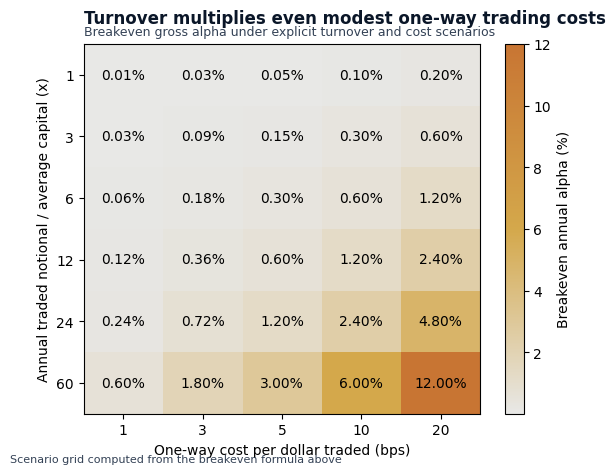

In [30]:
be_pivot = breakeven_df.pivot(
    on="one_way_cost_bps",
    index="annual_traded_notional",
    values="breakeven_alpha_pct",
).sort("annual_traded_notional")
be_data = be_pivot.drop("annual_traded_notional").to_numpy()
turnover_labels = be_pivot["annual_traded_notional"].to_list()
cost_labels = [int(column) for column in be_pivot.columns[1:]]

fig, ax = plt.subplots()
cost_cmap = LinearSegmentedColormap.from_list(
    "ml4t_cost",
    [COLORS["silver_muted"], COLORS["amber"], COLORS["copper"]],
)
im = ax.imshow(be_data, cmap=cost_cmap, aspect="auto")
ax.set_xticks(range(len(cost_labels)), labels=cost_labels)
ax.set_yticks(range(len(turnover_labels)), labels=turnover_labels)
ax.set_xlabel("One-way cost per dollar traded (bps)")
ax.set_ylabel("Annual traded notional / average capital (x)")
for row_idx in range(len(turnover_labels)):
    for col_idx in range(len(cost_labels)):
        ax.text(col_idx, row_idx, f"{be_data[row_idx, col_idx]:.2f}%", ha="center", va="center")

fig.colorbar(im, ax=ax, label="Breakeven annual alpha (%)")
add_message_title(
    ax,
    "Turnover multiplies even modest one-way trading costs",
    subtitle="Breakeven gross alpha under explicit turnover and cost scenarios",
    source="Scenario grid computed from the breakeven formula above",
)
fig.show()

In [31]:
example_turnover = 12
example_cost_bps = 5
example_breakeven = breakeven_df.filter(
    (pl.col("annual_traded_notional") == example_turnover)
    & (pl.col("one_way_cost_bps") == example_cost_bps)
)["breakeven_alpha_pct"].item()
display(
    Markdown(
        f"**Sensitivity reading:** Trading {example_turnover} times average capital per year at "
        f"{example_cost_bps} bps per dollar requires {example_breakeven:.2f}% annual gross alpha "
        "just to cover transaction costs. A case-study claim needs measured turnover and a "
        "compatible cost model before it can use this formula."
    )
)

**Sensitivity reading:** Trading 12 times average capital per year at 5 bps per dollar requires 0.60% annual gross alpha just to cover transaction costs. A case-study claim needs measured turnover and a compatible cost model before it can use this formula.

## 6. Borrow Costs for Long-Short Strategies

A long-short portfolio adds stock-borrow cost on the short allocation. Borrow
rates vary by security and date, so the curves below are scenarios rather than
a claim about a current market-wide rate.

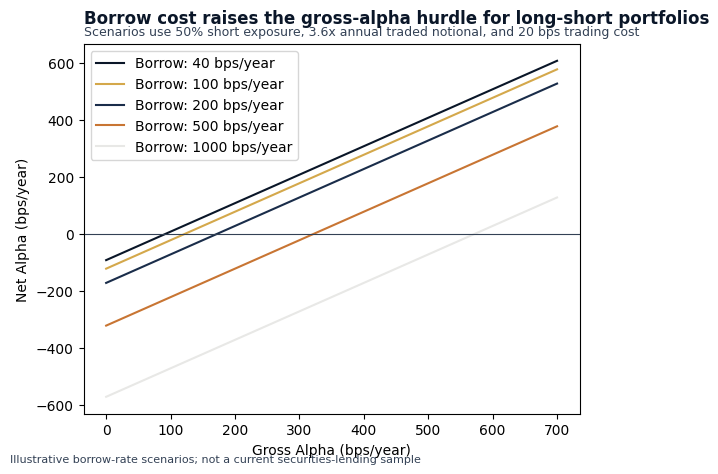

In [32]:
borrow_rate_scenarios = [40, 100, 200, 500, 1000]
short_allocation = 0.50
annual_traded_notional = 3.6
one_way_trading_cost_bps = 20
trading_cost_drag_bps = annual_traded_notional * one_way_trading_cost_bps
gross_alphas = np.linspace(0, 700, 120)

fig, ax = plt.subplots()
for borrow_bps, color in zip(
    borrow_rate_scenarios,
    ml4t_palette(len(borrow_rate_scenarios), categorical=True),
    strict=True,
):
    net_alpha = gross_alphas - trading_cost_drag_bps - borrow_bps * short_allocation
    ax.plot(gross_alphas, net_alpha, color=color, label=f"Borrow: {borrow_bps} bps/year")

ax.axhline(0, color=COLORS["neutral"], linewidth=0.8)
ax.set_xlabel("Gross Alpha (bps/year)")
ax.set_ylabel("Net Alpha (bps/year)")
ax.legend(loc="upper left")
add_message_title(
    ax,
    "Borrow cost raises the gross-alpha hurdle for long-short portfolios",
    subtitle=(
        f"Scenarios use {short_allocation:.0%} short exposure, {annual_traded_notional:.1f}x annual "
        f"traded notional, and {one_way_trading_cost_bps} bps trading cost"
    ),
    source="Illustrative borrow-rate scenarios; not a current securities-lending sample",
)

fig.show()

In [33]:
example_gross_alpha_bps = 200
low_borrow_bps = borrow_rate_scenarios[0]
high_borrow_bps = borrow_rate_scenarios[2]
low_borrow_net = example_gross_alpha_bps - trading_cost_drag_bps - low_borrow_bps * short_allocation
high_borrow_net = (
    example_gross_alpha_bps - trading_cost_drag_bps - high_borrow_bps * short_allocation
)
display(
    Markdown(
        f"**Scenario reading:** At {example_gross_alpha_bps} bps gross alpha, the modeled net "
        f"alpha is {low_borrow_net:.0f} bps with a {low_borrow_bps} bps borrow rate and "
        f"{high_borrow_net:.0f} bps with a {high_borrow_bps} bps rate. Both case studies with "
        "long-short construction flag borrow cost, but a production estimate needs security-level "
        "borrow observations."
    )
)

**Scenario reading:** At 200 bps gross alpha, the modeled net alpha is 108 bps with a 40 bps borrow rate and 28 bps with a 200 bps rate. Both case studies with long-short construction flag borrow cost, but a production estimate needs security-level borrow observations.

## Key Takeaways

1. **Units come first**: Share, contract, tick, spread, and notional fees
   require different trade details before they can be compared in bps.

2. **Liquidity conversions need a contract**: Equity share volume and crypto
   base volume support dollar-turnover estimates. Futures need multipliers.
   ETF volume paired with adjusted prices and FX tick volume must remain
   separate activity measures.

3. **Dominance is conditional**: Commission, spread, or impact can dominate
   depending on the stated volatility, liquidity, impact, and order-size inputs.

4. **Breakeven requires measured turnover**: A rebalance label cannot replace
   realized traded notional. Unsupported cost schemas must not receive a
   numeric fallback.

5. **Borrow is a separate state variable**: Long-short research needs dated,
   security-level borrow inputs in addition to trading costs.

**Next**: See `02_spread_estimation` for empirical spread estimates
and `03_market_impact_calibration` for impact model calibration.

**Book**: Chapter 18.1-18.2 provides the theoretical framework for
cost decomposition.